In [1]:
# %%
import json
import sys
import importlib
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances


PROJECT_ROOT = Path("../..").resolve()
sys.path.append(str(PROJECT_ROOT))

In [2]:
# %%
from src.counterfactuals.core import (
    BasisGenerator,
    TSFeatureSchema,
    TargetSpec,
    GeneratorConfig,
    LossWeights,
)

from src.counterfactuals.metrics import (
    evaluate_cf_set,
)

from src.train_cmapss_v3 import (
    create_model,
    load_cmapss_subset,
    DataConfig,
    DEFAULT_DATA_DIR,
    DEFAULT_OUTPUT_ROOT,
)

import src.baselines.forecast as forecast_module
importlib.reload(forecast_module)

from src.baselines.comte import CoMTEGenerator
from src.baselines.forecast import ForecastCFGenerator

/workspace/nirban/miniconda3/envs/nirban_base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# %%
SUBSET = "FD004"
MODEL_NAME = "transformer"

BASIS_TYPES = ["bspline", "rbf", "wavelet", "polynomial", "fourier"]
NUM_BASIS_GRID = [4, 6, 8, 10]

NUM_QUERY_SAMPLES = 20
NUM_CFS = 3
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7 else "cpu"
)
print("Using device:", device)

Using device: cuda


In [4]:
# %%
def predict_rul_normalised(model, sequence_np, device):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(sequence_np, dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(x).view(-1)[0].item()
    return float(pred)


def denorm_rul(val, rul_min, rul_range):
    return float(val * rul_range + rul_min)


def get_test_sample(test_loader, idx=0):
    offset = 0
    for batch in test_loader:
        X = batch[0]
        y = batch[-1]
        bsz = X.shape[0]
        if offset + bsz > idx:
            j = idx - offset
            return X[j].cpu().numpy(), float(y[j].cpu().item())
        offset += bsz
    raise IndexError(f"Index {idx} out of range")


def collect_labels(loader):
    labels = []
    for batch in loader:
        y = batch[-1]
        labels.extend(y.detach().cpu().numpy().flatten().tolist())
    return np.array(labels)


def compute_mad_inv_from_loader(loader, n_features, mad_floor=1e-2, mad_clip=50.0):
    all_data = []
    for batch in loader:
        X = batch[0].detach().cpu().numpy()
        all_data.append(X.reshape(-1, n_features))
    flat = np.concatenate(all_data, axis=0)
    med = np.median(flat, axis=0)
    mad = np.median(np.abs(flat - med), axis=0)
    mad = np.maximum(mad, mad_floor)
    mad_inv = 1.0 / mad
    mad_inv = np.clip(mad_inv, 0.0, mad_clip)
    return mad_inv.astype(np.float32)


def make_target_spec(
    pred_norm: float,
    rul_min: float,
    rul_range: float,
    max_rul: float,
    increase_cycles: Tuple[float, float] = (15.0, 30.0),
    band_half_width_cycles: float = 2.5,
):
    current_rul = denorm_rul(pred_norm, rul_min, rul_range)

    low_inc, high_inc = increase_cycles
    feasible_high = min(high_inc, max(0.0, max_rul - current_rul))

    if feasible_high < low_inc:
        target_rul = min(current_rul + low_inc, max_rul)
    else:
        target_rul = current_rul + np.random.uniform(low_inc, feasible_high)

    target_norm = (target_rul - rul_min) / max(rul_range, 1e-8)
    band_half_norm = band_half_width_cycles / max(rul_range, 1e-8)

    lo = max(0.0, target_norm - band_half_norm)
    hi = min(1.0, target_norm + band_half_norm)

    target = TargetSpec(
        task_type="regression",
        target_value=float(target_norm),
        target_range=(float(lo), float(hi)),
    )
    return target, float(target_rul), float(target_norm), float(lo), float(hi)


def append_series_records(
    records: List[dict],
    query_idx: int,
    series_np: np.ndarray,
    feature_cols: List[str],
    series_type: str,
    method: str,
    K,
    cf_id: int,
    pred_norm: float,
    pred_rul: float,
    target_norm: float,
    target_rul: float,
):
    T, D = series_np.shape
    for t in range(T):
        for d in range(D):
            records.append({
                "query_idx": int(query_idx),
                "series_type": series_type,
                "method": method,
                "K": K,
                "cf_id": int(cf_id),
                "t": int(t),
                "feature_idx": int(d),
                "feature_name": feature_cols[d],
                "value": float(series_np[t, d]),
                "pred_norm": float(pred_norm),
                "pred_rul": float(pred_rul),
                "target_norm": float(target_norm),
                "target_rul": float(target_rul),
            })


def append_x_vs_xcf_records(
    records,
    query_idx: int,
    x_np: np.ndarray,
    xcf_np: np.ndarray,
    feature_cols: list,
    method: str,
    K,
    cf_id: int,
    pred_rul_orig: float,
    pred_rul_cf: float,
    target_rul: float,
):
    T, D = x_np.shape
    delta_np = xcf_np - x_np

    for t in range(T):
        for d in range(D):
            records.append({
                "query_idx": int(query_idx),
                "method": method,
                "K": K,
                "cf_id": int(cf_id),
                "t": int(t),
                "feature_idx": int(d),
                "feature_name": feature_cols[d],
                "x": float(x_np[t, d]),
                "x_cf": float(xcf_np[t, d]),
                "delta": float(delta_np[t, d]),
                "abs_delta": float(abs(delta_np[t, d])),
                "pred_rul_orig": float(pred_rul_orig),
                "pred_rul_cf": float(pred_rul_cf),
                "target_rul": float(target_rul),
            })


def build_eval_row(
    query_idx: int,
    method: str,
    K,
    pred_rul_orig: float,
    target_rul: float,
    target_norm: float,
    band_lo: float,
    band_hi: float,
    metrics: Dict[str, float],
    rul_min: float,
    rul_range: float,
):
    pred_norm_cf = float(metrics["pred_summary"])
    pred_rul_cf = denorm_rul(pred_norm_cf, rul_min, rul_range)

    return {
        "query_idx": int(query_idx),
        "method": method,
        "K": K,
        "pred_rul_orig": float(pred_rul_orig),
        "pred_rul_cf": float(pred_rul_cf),
        "target_rul": float(target_rul),
        "target_norm": float(target_norm),
        "band_lo_norm": float(band_lo),
        "band_hi_norm": float(band_hi),
        "band_lo_rul": denorm_rul(band_lo, rul_min, rul_range),
        "band_hi_rul": denorm_rul(band_hi, rul_min, rul_range),
        "validity": float(metrics["validity"]),
        "proximity": float(metrics["proximity"]),
        "coeff_sparsity": float(metrics["coeff_sparsity"]),
        "group_sparsity": float(metrics["group_sparsity"]),
        "smoothness": float(metrics["smoothness"]),
        "diversity": float(metrics["diversity"]),
        "total": float(metrics["total"]),
        "is_valid": bool(metrics["is_valid"]),
        "pred_summary": float(metrics["pred_summary"]),
        "point_gap_norm": float(metrics["point_gap"]),
        "band_hit": bool(metrics["is_valid"]),
    }

In [5]:
# %%
data_cfg = DataConfig(
    data_dir=DEFAULT_DATA_DIR,
    subsets=[SUBSET],
    seq_len=50,
    batch_size=32,
    smoothing_window=3,
    split_context=False,
    seed=SEED,
    feature_mode="selected",
    piecewise_rul_cap=125,
    val_strategy="engine",
    val_fraction=0.20,
    test_last_window_only=True,
    shuffle_train=True,
    target_normalisation=True,
    cluster_by_operating_condition=True,
    n_clusters=6,
    drop_constant_features=False,
)

# If your patched loader supports return_dataset=True, use:
try:
    train_loader, val_loader, test_loader, preprocess, cmapss_ds = load_cmapss_subset(
        data_cfg, SUBSET, return_dataset=True
    )
    print("Dataset metadata support: ON")
except TypeError:
    train_loader, val_loader, test_loader, preprocess = load_cmapss_subset(data_cfg, SUBSET)
    cmapss_ds = None
    print("Dataset metadata support: OFF")

feature_cols = preprocess["feature_cols"]
seq_len = preprocess["seq_len"]
n_features = preprocess["n_features"]
rul_min = preprocess["rul_min"]
rul_range = preprocess["rul_range"]
max_rul = preprocess["max_rul"]

print(f"Features ({n_features}): {feature_cols}")
print(f"Sequence length: {seq_len}")

[FD004] train=38383, val=9918, test=248 | seq_len=50, n_features=7, feature_mode=selected, val_strategy=engine, cap=125, batch=32, test_last_window_only=True
Dataset metadata support: ON
Features (7): ['setting_1', 'setting_2', 'setting_3', 's_2', 's_8', 's_14', 's_16']
Sequence length: 50


In [6]:
print(type(cmapss_ds))
print(hasattr(cmapss_ds, "last_U_test"))
print(hasattr(cmapss_ds, "last_test_processed_df"))
print(cmapss_ds.last_U_test.shape)
print(cmapss_ds.last_test_processed_df.head())

<class 'src.data_loader.cmapss.v2.CMAPSSTorchDataloader_v2.CMAPSSTorchDataset'>
True
True
(248, 50, 2)
   unit_number  time_cycles  setting_1  setting_2  setting_3       s_2  \
0            1            3   0.690389   0.855899   0.666667  0.308350   
1            1            4   0.864930   0.911401   0.666667  0.330023   
2            1            5   0.944355   0.998496   1.000000  0.343015   
3            1            6   0.809468   0.910728   0.666667  0.329096   
4            1            7   0.634867   0.855819   0.666667  0.369115   

        s_8      s_14  s_16  RUL  
0  0.209641  0.145859   0.0  1.0  
1  0.267142  0.168464   0.0  1.0  
2  0.245702  0.168927   0.0  1.0  
3  0.218464  0.179487   0.0  1.0  
4  0.154588  0.165082   0.0  1.0  


In [7]:
# %%
RUN_DIR = Path(DEFAULT_OUTPUT_ROOT) / SUBSET / MODEL_NAME
model_spec_path = RUN_DIR / "model_spec.json"

if model_spec_path.exists():
    with open(model_spec_path) as f:
        model_spec_dict = json.load(f)
    model_kwargs = model_spec_dict.get("model_kwargs", {})
else:
    model_kwargs = {"d_model": 128, "nhead": 4, "num_layers": 2, "dropout": 0.2}

model = create_model(
    model_name=MODEL_NAME,
    input_size=n_features,
    device=device,
    seq_len=seq_len,
    max_rul=max_rul,
    model_kwargs=model_kwargs,
)

ckpt_candidates = list(RUN_DIR.glob("*.ckpt")) + list(RUN_DIR.glob("*best*.pth"))
if not ckpt_candidates:
    raise FileNotFoundError(f"No checkpoint found in {RUN_DIR}")

ckpt_path = ckpt_candidates[0]
checkpoint = torch.load(ckpt_path, map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
else:
    model.load_state_dict(checkpoint, strict=False)

model.eval()
print("Loaded checkpoint:", ckpt_path)

TRANSFORMER parameters: 274,305
Loaded checkpoint: /workspace/nirban/vaibhav/counterfactual_basis_kernel/outputs/cmapss/v2/FD004/transformer/transformer_FD004_best.ckpt


In [8]:
# %%
settings_features = [f for f in feature_cols if f.lower().startswith("setting")]
sensor_features = [f for f in feature_cols if f not in settings_features]
settings_idxs = [feature_cols.index(f) for f in settings_features]
sensor_idxs = [feature_cols.index(f) for f in sensor_features]

roles = ["immutable" if f in settings_features else "action" for f in feature_cols]
mad_inv = compute_mad_inv_from_loader(train_loader, n_features)

action_groups = {
    f"ch_{j}_{feature_cols[j]}": [j]
    for j, role in enumerate(roles)
    if role == "action"
}

cmapss_schema = TSFeatureSchema(
    feature_names=feature_cols,
    roles=roles,
    min_vals=np.zeros(n_features, dtype=np.float32),
    max_vals=np.ones(n_features, dtype=np.float32),
    mad_inv=mad_inv.astype(np.float32),
    action_groups=action_groups,
)

print(f"Schema features: {cmapss_schema.D}")
print(f"Immutable: {sum(r == 'immutable' for r in roles)}")
print(f"Action:    {sum(r == 'action' for r in roles)}")

Schema features: 7
Immutable: 3
Action:    4


In [9]:
# %%
loss_weights = LossWeights(
    validity=1.0,
    proximity=0.50,
    sparsity=0.02,
    diversity=0.20,
    smoothness=0.25,
    channel_sparsity=0.15,
    state_lock=0.0,
)

gen_config = GeneratorConfig(
    editable_roles=("action",),
    allow_state_edits=False,
    init_std=0.05,
    lr=0.02,
    max_iter=500,
    eta_min=1e-4,
    gradient_clip_norm=1.0,
    early_stop_tol_reg=0.01,
    early_stop_patience=120,
    clamp_during_optim=True,
    num_restarts=8,
    adam_steps=500,
    lbfgs_steps=0,         # keep 0 for diversity mode
    rho_init=10.0,
    rho_growth=1.4,
    rho_max=1e4,
    prevalid_cleanup_scale=0.10,
    div_start_frac=0.15,   # activate diversity early
)

print("Optimisation config loaded")

Optimisation config loaded


In [10]:
# %%
basis_generators = {}
for b in BASIS_TYPES:
    basis_generators[b] = {}
    for K in NUM_BASIS_GRID:
        basis_generators[b][K] = BasisGenerator(
            model=model,
            sequence_length=seq_len,
            feature_dim=n_features,
            basis_type=b,
            num_basis=K,
            device=str(device),
            config=gen_config,
        )

baseline_generators = {
    "comte": CoMTEGenerator(
        model=model,
        sequence_length=seq_len,
        feature_dim=n_features,
        device=str(device),
        config=gen_config,
        mode="standard",
    ),
    "forecast": ForecastCFGenerator(
        model=model,
        sequence_length=seq_len,
        feature_dim=n_features,
        device=str(device),
        config=gen_config,
    ),
}

print("Generators initialised")

Generators initialised


In [11]:
def mean_pairwise_distance_from_cfs(cfs: torch.Tensor) -> float:
    """
    cfs: (N, T, D)
    Returns mean pairwise Euclidean distance over flattened CFs.
    """
    x = cfs.detach().cpu().numpy().reshape(cfs.shape[0], -1)
    if x.shape[0] <= 1:
        return 0.0
    D = pairwise_distances(x, metric="euclidean")
    tri = D[np.triu_indices_from(D, k=1)]
    return float(np.mean(tri)) if tri.size > 0 else 0.0

In [12]:
# %%
def run_single_query(
    query_idx: int,
    train_loader,
    test_loader,
    model,
    cmapss_schema,
    basis_generators,
    baseline_generators,
    feature_cols,
    rul_min,
    rul_range,
    max_rul,
    device,
    num_cfs: int = 3,
):
    query_np, true_y_norm = get_test_sample(test_loader, idx=int(query_idx))
    pred_norm = predict_rul_normalised(model, query_np, device)
    pred_rul = denorm_rul(pred_norm, rul_min, rul_range)

    target, target_rul, target_norm, lo, hi = make_target_spec(
        pred_norm=pred_norm,
        rul_min=rul_min,
        rul_range=rul_range,
        max_rul=max_rul,
        increase_cycles=(15.0, 30.0),
        band_half_width_cycles=2.5,
    )

    print(f"\nQuery idx={query_idx} | pred={pred_rul:.2f} | target≈{target_rul:.2f}")

    query_tensor = torch.tensor(query_np, dtype=torch.float32, device=device)

    eval_records = []
    x_vs_xcf_records = []
    cf_bank_records = []

    append_series_records(
        records=cf_bank_records,
        query_idx=int(query_idx),
        series_np=query_np,
        feature_cols=feature_cols,
        series_type="original",
        method="original",
        K=None,
        cf_id=0,
        pred_norm=pred_norm,
        pred_rul=pred_rul,
        target_norm=target_norm,
        target_rul=target_rul,
    )

    # ---------- basis methods ----------
    for basis_type in BASIS_TYPES:
        best_run = None
        best_cfs_np = None

        for K in NUM_BASIS_GRID:
            cfs, info = basis_generators[basis_type][K].generate(
                query_instance=query_tensor,
                target=target,
                schema=cmapss_schema,
                num_cfs=num_cfs,
                loss_weights=loss_weights,
                verbose=False,
            )

            cfs_np = cfs.detach().cpu().numpy()

            # print("cfs shape:", cfs.shape)
            # for i in range(cfs.shape[0]):
            #     for j in range(i + 1, cfs.shape[0]):
            #         d = torch.norm(cfs[i] - cfs[j]).item()
            #         print(f"||CF{i+1} - CF{j+1}|| = {d:.8f}")

            metrics = evaluate_cf_set(
                model=model,
                x_orig=query_tensor,
                x_cf=cfs,
                target=target,
                schema=cmapss_schema,
                device=device,
                W=None,
                prox_mode="raw_mean",
            )
            pairwise_div = mean_pairwise_distance_from_cfs(cfs)

            this = {
                "K": K,
                "validity": metrics["validity"],
                "proximity": metrics["proximity"],
                "coeff_sparsity": metrics["coeff_sparsity"],
                "group_sparsity": metrics["group_sparsity"],
                "smoothness": metrics["smoothness"],
                "diversity": metrics["diversity"],
                "diversity_pairwise": pairwise_div,
                "total": metrics["total"],
                "is_valid": float(metrics["is_valid"]),
                "pred_summary": metrics["pred_summary"],
                "point_gap": metrics["point_gap"],
            }

            if best_run is None:
                best_run = this
                best_cfs_np = cfs_np
            else:
                old_key = (
                    0.0 if best_run["is_valid"] else 1.0,
                    best_run["validity"],
                    best_run["proximity"],
                    best_run["group_sparsity"],
                    best_run["smoothness"],
                    -best_run["diversity"],
                )
                new_key = (
                    0.0 if this["is_valid"] else 1.0,
                    this["validity"],
                    this["proximity"],
                    this["group_sparsity"],
                    this["smoothness"],
                    -this["diversity"],
                )
                if new_key < old_key:
                    best_run = this
                    best_cfs_np = cfs_np

        print(
            f"  {basis_type:10s} K={best_run['K']:2d} | "
            f"validity={best_run['validity']:.6f} | "
            f"point_gap={best_run['point_gap']:.6f} | "
            f"proximity={best_run['proximity']:.6f} | "
            f"group={best_run['group_sparsity']:.6f} | "
            f"smoothness={best_run['smoothness']:.3e} | "
            f"logdet_div={best_run['diversity']:.6f} | "
            f"pair_div={best_run['diversity_pairwise']:.6f} | "
            f"valid={bool(best_run['is_valid'])}"
        )

        eval_records.append(
            build_eval_row(
                query_idx=query_idx,
                method=basis_type,
                K=best_run["K"],
                pred_rul_orig=pred_rul,
                target_rul=target_rul,
                target_norm=target_norm,
                band_lo=lo,
                band_hi=hi,
                metrics=best_run,
                rul_min=rul_min,
                rul_range=rul_range,
            )
        )

        best_cf_pred_norm = float(best_run["pred_summary"])
        best_cf_pred_rul = denorm_rul(best_cf_pred_norm, rul_min, rul_range)

        for cf_id in range(best_cfs_np.shape[0]):
            cf_i_np = best_cfs_np[cf_id]

            append_series_records(
                records=cf_bank_records,
                query_idx=int(query_idx),
                series_np=cf_i_np,
                feature_cols=feature_cols,
                series_type="cf",
                method=basis_type,
                K=best_run["K"],
                cf_id=cf_id,
                pred_norm=best_cf_pred_norm,
                pred_rul=best_cf_pred_rul,
                target_norm=target_norm,
                target_rul=target_rul,
            )

            append_x_vs_xcf_records(
                records=x_vs_xcf_records,
                query_idx=int(query_idx),
                x_np=query_np,
                xcf_np=cf_i_np,
                feature_cols=feature_cols,
                method=basis_type,
                K=best_run["K"],
                cf_id=cf_id,
                pred_rul_orig=pred_rul,
                pred_rul_cf=best_cf_pred_rul,
                target_rul=target_rul,
            )

    # ---------- baselines ----------
    for baseline_name, baseline_gen in baseline_generators.items():
        cfs, info = baseline_gen.generate(
            query_instance=query_tensor,
            target=target,
            schema=cmapss_schema,
            num_cfs=num_cfs,
            loss_weights=loss_weights,
            verbose=False,
        )

        cfs_np = cfs.detach().cpu().numpy()

        metrics = evaluate_cf_set(
            model=model,
            x_orig=query_tensor,
            x_cf=cfs,
            target=target,
            schema=cmapss_schema,
            device=device,
            W=None,
            prox_mode="raw_mean",
        )
        pairwise_div = mean_pairwise_distance_from_cfs(cfs)

        this = {
            "K": None,
            "validity": metrics["validity"],
            "proximity": metrics["proximity"],
            "coeff_sparsity": metrics["coeff_sparsity"],
            "group_sparsity": metrics["group_sparsity"],
            "smoothness": metrics["smoothness"],
            "diversity": metrics["diversity"],
            "diversity_pairwise": pairwise_div,
            "total": metrics["total"],
            "is_valid": float(metrics["is_valid"]),
            "pred_summary": metrics["pred_summary"],
            "point_gap": metrics["point_gap"],
        }

        print(
            f"  {basis_type:10s} K={best_run['K']:2d} | "
            f"validity={best_run['validity']:.6f} | "
            f"point_gap={best_run['point_gap']:.6f} | "
            f"proximity={best_run['proximity']:.6f} | "
            f"group={best_run['group_sparsity']:.6f} | "
            f"smoothness={best_run['smoothness']:.3e} | "
            f"logdet_div={best_run['diversity']:.6f} | "
            f"pair_div={best_run['diversity_pairwise']:.6f} | "
            f"valid={bool(best_run['is_valid'])}"
        )

        eval_records.append(
            build_eval_row(
                query_idx=query_idx,
                method=baseline_name,
                K=None,
                pred_rul_orig=pred_rul,
                target_rul=target_rul,
                target_norm=target_norm,
                band_lo=lo,
                band_hi=hi,
                metrics=this,
                rul_min=rul_min,
                rul_range=rul_range,
            )
        )

        cf_pred_norm = float(this["pred_summary"])
        cf_pred_rul = denorm_rul(cf_pred_norm, rul_min, rul_range)

        for cf_id in range(cfs_np.shape[0]):
            cf_i_np = cfs_np[cf_id]

            append_series_records(
                records=cf_bank_records,
                query_idx=int(query_idx),
                series_np=cf_i_np,
                feature_cols=feature_cols,
                series_type="cf",
                method=baseline_name,
                K=None,
                cf_id=cf_id,
                pred_norm=cf_pred_norm,
                pred_rul=cf_pred_rul,
                target_norm=target_norm,
                target_rul=target_rul,
            )

            append_x_vs_xcf_records(
                records=x_vs_xcf_records,
                query_idx=int(query_idx),
                x_np=query_np,
                xcf_np=cf_i_np,
                feature_cols=feature_cols,
                method=baseline_name,
                K=None,
                cf_id=cf_id,
                pred_rul_orig=pred_rul,
                pred_rul_cf=cf_pred_rul,
                target_rul=target_rul,
            )

    eval_df = pd.DataFrame(eval_records)
    cf_bank_df = pd.DataFrame(cf_bank_records)
    x_vs_xcf_df = pd.DataFrame(x_vs_xcf_records)

    return {
        "query_idx": query_idx,
        "pred_rul_orig": pred_rul,
        "target_rul": target_rul,
        "eval_df": eval_df,
        "cf_bank_df": cf_bank_df,
        "x_vs_xcf_df": x_vs_xcf_df,
    }

In [13]:
# # %%
# single_run = run_single_query(
#     query_idx=83,
#     train_loader=train_loader,
#     test_loader=test_loader,
#     model=model,
#     cmapss_schema=cmapss_schema,
#     basis_generators=basis_generators,
#     baseline_generators=baseline_generators,
#     feature_cols=feature_cols,
#     rul_min=rul_min,
#     rul_range=rul_range,
#     max_rul=max_rul,
#     device=device,
#     num_cfs=NUM_CFS,
# )

# single_eval_df = single_run["eval_df"]
# single_cf_bank_df = single_run["cf_bank_df"]
# single_x_vs_xcf_df = single_run["x_vs_xcf_df"]

# single_eval_df

In [14]:
# %%
np.random.seed(SEED)
test_labels = collect_labels(test_loader)
all_indices = np.arange(len(test_labels))
query_indices = np.random.choice(all_indices, size=min(NUM_QUERY_SAMPLES, len(all_indices)), replace=False)

print("Total test windows:", len(all_indices))
print("Selected queries:", query_indices)

Total test windows: 248
Selected queries: [ 33   6 182  86 156 246 195 104   9 235 232 236 238 178  66 158 192  15
 183  24]


In [15]:
# %%
results: Dict[str, List[Dict]] = {name: [] for name in BASIS_TYPES + ["comte", "forecast"]}
cf_bank_records: List[dict] = []
eval_records: List[dict] = []
x_vs_xcf_records: List[dict] = []

for q_idx in query_indices:
    out = run_single_query(
        query_idx=int(q_idx),
        train_loader=train_loader,
        test_loader=test_loader,
        model=model,
        cmapss_schema=cmapss_schema,
        basis_generators=basis_generators,
        baseline_generators=baseline_generators,
        feature_cols=feature_cols,
        rul_min=rul_min,
        rul_range=rul_range,
        max_rul=max_rul,
        device=device,
        num_cfs=NUM_CFS,
    )

    eval_records.extend(out["eval_df"].to_dict("records"))
    cf_bank_records.extend(out["cf_bank_df"].to_dict("records"))
    x_vs_xcf_records.extend(out["x_vs_xcf_df"].to_dict("records"))


Query idx=33 | pred=103.09 | target≈124.59
  bspline    K= 8 | validity=0.000000 | point_gap=0.018578 | proximity=0.000005 | group=0.052994 | smoothness=1.531e-07 | logdet_div=-6.708846 | pair_div=0.006287 | valid=True
  rbf        K=10 | validity=0.000000 | point_gap=0.019551 | proximity=0.000004 | group=0.045404 | smoothness=4.174e-09 | logdet_div=-6.717256 | pair_div=0.005871 | valid=True
  wavelet    K=10 | validity=0.000000 | point_gap=0.019720 | proximity=0.000012 | group=0.074854 | smoothness=3.449e-06 | logdet_div=-6.788046 | pair_div=0.009001 | valid=True
  polynomial K=10 | validity=0.000000 | point_gap=0.019927 | proximity=0.000004 | group=0.047809 | smoothness=1.571e-08 | logdet_div=-5.607124 | pair_div=0.008731 | valid=True
  fourier    K=10 | validity=0.000000 | point_gap=0.019455 | proximity=0.000006 | group=0.053458 | smoothness=8.416e-08 | logdet_div=-7.332057 | pair_div=0.004644 | valid=True
  fourier    K=10 | validity=0.000000 | point_gap=0.019455 | proximity=0.000

In [16]:
# %%
eval_df = pd.DataFrame(eval_records)
cf_bank_df = pd.DataFrame(cf_bank_records)
x_vs_xcf_df = pd.DataFrame(x_vs_xcf_records)

print("eval_df shape   :", eval_df.shape)
print("cf_bank_df shape:", cf_bank_df.shape)
print("x_vs_xcf_df shape:", x_vs_xcf_df.shape)

print("\neval_df columns:", eval_df.columns.tolist())
print("\ncf_bank_df columns:", cf_bank_df.columns.tolist())
print("\nx_vs_xcf_df columns:", x_vs_xcf_df.columns.tolist())

eval_df shape   : (140, 22)
cf_bank_df shape: (154000, 13)
x_vs_xcf_df shape: (147000, 14)

eval_df columns: ['query_idx', 'method', 'K', 'pred_rul_orig', 'pred_rul_cf', 'target_rul', 'target_norm', 'band_lo_norm', 'band_hi_norm', 'band_lo_rul', 'band_hi_rul', 'validity', 'proximity', 'coeff_sparsity', 'group_sparsity', 'smoothness', 'diversity', 'total', 'is_valid', 'pred_summary', 'point_gap_norm', 'band_hit']

cf_bank_df columns: ['query_idx', 'series_type', 'method', 'K', 'cf_id', 't', 'feature_idx', 'feature_name', 'value', 'pred_norm', 'pred_rul', 'target_norm', 'target_rul']

x_vs_xcf_df columns: ['query_idx', 'method', 'K', 'cf_id', 't', 'feature_idx', 'feature_name', 'x', 'x_cf', 'delta', 'abs_delta', 'pred_rul_orig', 'pred_rul_cf', 'target_rul']


In [17]:
# %%
print("\n" + "=" * 96)
print("AVERAGE RESULTS")
print("=" * 96)

for name in BASIS_TYPES + ["comte", "forecast"]:
    vals = eval_df[eval_df["method"] == name]
    if len(vals) == 0:
        continue

    print(
        f"{name:10s} | "
        f"hit_rate={vals['is_valid'].mean():.3f} | "
        f"validity={vals['validity'].mean():.6f} | "
        f"proximity={vals['proximity'].mean():.6f} | "
        f"coeff_sparse={vals['coeff_sparsity'].mean():.6f} | "
        f"group_sparse={vals['group_sparsity'].mean():.6f} | "
        f"smoothness={vals['smoothness'].mean():.6f} | "
        f"diversity={vals['diversity'].mean():.6f} | "
        f"total={vals['total'].mean():.6f}"
    )


AVERAGE RESULTS
bspline    | hit_rate=1.000 | validity=0.000000 | proximity=0.000040 | coeff_sparse=nan | group_sparse=0.137267 | smoothness=0.000006 | diversity=-7.302176 | total=0.137313
rbf        | hit_rate=1.000 | validity=0.000000 | proximity=0.000034 | coeff_sparse=nan | group_sparse=0.123949 | smoothness=0.000000 | diversity=-7.039740 | total=0.123983
wavelet    | hit_rate=1.000 | validity=0.000000 | proximity=0.000089 | coeff_sparse=nan | group_sparse=0.214637 | smoothness=0.000024 | diversity=-6.676050 | total=0.214751
polynomial | hit_rate=1.000 | validity=0.000000 | proximity=0.000031 | coeff_sparse=nan | group_sparse=0.114515 | smoothness=0.000001 | diversity=-8.050992 | total=0.114547
fourier    | hit_rate=1.000 | validity=0.000000 | proximity=0.000039 | coeff_sparse=nan | group_sparse=0.135017 | smoothness=0.000000 | diversity=-7.822496 | total=0.135056
comte      | hit_rate=0.600 | validity=0.000815 | proximity=0.000085 | coeff_sparse=nan | group_sparse=0.288181 | smoo

In [41]:
x_vs_xcf_df[x_vs_xcf_df["query_idx"] == 6]

,query_idx,method,K,cf_id,t,feature_idx,feature_name,x,x_cf,delta,abs_delta,pred_rul_orig,pred_rul_cf,target_rul
7350,6,bspline,8.0,0,0,0,setting_1,0.238107,0.238107,0.000000,0.000000,69.198512,89.195393,91.641007
7351,6,bspline,8.0,0,0,1,setting_2,0.376762,0.376762,0.000000,0.000000,69.198512,89.195393,91.641007
7352,6,bspline,8.0,0,0,2,setting_3,1.000000,1.000000,0.000000,0.000000,69.198512,89.195393,91.641007
7353,6,bspline,8.0,0,0,3,s_2,0.571194,0.582283,0.011089,0.011089,69.198512,89.195393,91.641007
7354,6,bspline,8.0,0,0,4,s_8,0.455620,0.455938,0.000319,0.000319,69.198512,89.195393,91.641007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14695,6,forecast,NaN,2,49,2,setting_3,1.000000,1.000000,0.000000,0.000000,69.198512,91.466233,91.641007
14696,6,forecast,NaN,2,49,3,s_2,0.566345,0.557670,-0.008675,0.008675,69.198512,91.466233,91.641007
14697,6,forecast,NaN,2,49,4,s_8,0.455639,0.456260,0.000620,0.000620,69.198512,91.466233,91.641007
14698,6,forecast,NaN,2,49,5,s_14,0.221188,0.230719,0.009531,0.009531,69.198512,91.466233,91.641007


In [18]:
# %%
def diversity_audit_from_df(x_vs_xcf_df: pd.DataFrame):
    rows = []

    for keys, g in x_vs_xcf_df.groupby(["query_idx", "method", "K"], dropna=False):
        query_idx, method, K = keys
        cf_ids = sorted(g["cf_id"].unique().tolist())

        if len(cf_ids) <= 1:
            continue

        vecs = []
        for cf_id in cf_ids:
            tmp = g[g["cf_id"] == cf_id].sort_values(["t", "feature_idx"])
            vecs.append(tmp["delta"].to_numpy())

        X = np.vstack(vecs)
        D = pairwise_distances(X, metric="euclidean")
        tri = D[np.triu_indices_from(D, k=1)]

        rows.append({
            "query_idx": query_idx,
            "method": method,
            "K": K,
            "n_cf": len(cf_ids),
            "mean_pairwise_dist": float(np.mean(tri)) if tri.size > 0 else 0.0,
            "max_pairwise_dist": float(np.max(tri)) if tri.size > 0 else 0.0,
            "collapsed": bool(np.max(tri) < 1e-8),
        })

    return pd.DataFrame(rows)

div_audit_df = diversity_audit_from_df(x_vs_xcf_df)
div_audit_df.head()

,query_idx,method,K,n_cf,mean_pairwise_dist,max_pairwise_dist,collapsed
0,6,bspline,8.0,3,0.001187,0.001461,False
1,6,comte,NaN,3,0.086032,0.096987,False
2,6,forecast,NaN,3,0.097965,0.122181,False
3,6,fourier,10.0,3,0.003877,0.004163,False
4,6,polynomial,10.0,3,0.002382,0.002614,False


In [19]:
# %%
div_summary = (
    div_audit_df.groupby("method", dropna=False)
    .agg(
        mean_pairwise_dist=("mean_pairwise_dist", "mean"),
        max_pairwise_dist=("max_pairwise_dist", "mean"),
        collapse_rate=("collapsed", "mean"),
    )
    .sort_values("mean_pairwise_dist", ascending=False)
)

div_summary

,mean_pairwise_dist,max_pairwise_dist,collapse_rate
method,,,
forecast,0.095734,0.116369,0.00
comte,0.093035,0.118569,0.00
wavelet,0.035677,0.046428,0.20
bspline,0.016948,0.022720,0.15
rbf,0.008875,0.010874,0.05
fourier,0.005439,0.006384,0.05
polynomial,0.002504,0.003079,0.10


In [20]:
# %%
save_dir = Path("cf_experiment_outputs") / SUBSET
save_dir.mkdir(parents=True, exist_ok=True)

eval_df.to_csv(save_dir / f"eval_df_{SUBSET}.csv", index=False)
cf_bank_df.to_csv(save_dir / f"cf_bank_df_{SUBSET}.csv", index=False)
x_vs_xcf_df.to_csv(save_dir / f"x_vs_xcf_df_{SUBSET}.csv", index=False)
div_audit_df.to_csv(save_dir / f"div_audit_df_{SUBSET}.csv", index=False)

eval_df.to_pickle(save_dir / f"eval_df_{SUBSET}.pkl")
cf_bank_df.to_pickle(save_dir / f"cf_bank_df_{SUBSET}.pkl")
x_vs_xcf_df.to_pickle(save_dir / f"x_vs_xcf_df_{SUBSET}.pkl")
div_audit_df.to_pickle(save_dir / f"div_audit_df_{SUBSET}.pkl")

print("Saved to:", save_dir.resolve())

Saved to: /workspace/nirban/vaibhav/counterfactual_basis_kernel/notebooks/cmapss/cf_experiment_outputs/FD004


In [42]:
# %%
import os

colors_map = {
    "fourier": "#e74c3c",
    "bspline": "#3498db",
    "wavelet": "#2ecc71",
    "polynomial": "#9b59b6",
    "rbf": "#f39c12",
    "comte": "#472323",
    "forecast": "#5C887F",
}

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def savefig300(fig, save_path=None):
    if save_path is not None:
        save_path = str(save_path)
        out_dir = os.path.dirname(save_path)
        if out_dir:
            ensure_dir(out_dir)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def get_rows(x_vs_xcf_df, query_idx, method=None, cf_id=None, feature_name=None):
    df = x_vs_xcf_df[x_vs_xcf_df["query_idx"] == query_idx].copy()
    if method is not None:
        df = df[df["method"] == method]
    if cf_id is not None:
        df = df[df["cf_id"] == cf_id]
    if feature_name is not None:
        df = df[df["feature_name"] == feature_name]
    return df

def top_changed_features_df(
    x_vs_xcf_df, query_idx, method, top_n=4, exclude_feature_idxs=None
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method)
    if exclude_feature_idxs is not None and len(exclude_feature_idxs) > 0:
        df = df[~df["feature_idx"].isin(exclude_feature_idxs)]

    out = (
        df.groupby(["feature_idx", "feature_name"], as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)
        .head(top_n)
    )
    return out

In [63]:
# %%
def plot_window_diversity_overlay(
    x_vs_xcf_df,
    query_idx,
    method,
    feature_name,
    save_path=None,
    figsize=(12, 5),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method, feature_name=feature_name)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    fig, ax = plt.subplots(figsize=figsize)

    orig_df = df[df["cf_id"] == cf_ids[0]].sort_values("t")
    pred_rul_orig = float(orig_df["pred_rul_orig"].iloc[0])
    target_rul = float(orig_df["target_rul"].iloc[0])

    ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.6, label=f"Original (RUL={pred_rul_orig:.0f})")

    for j, cf_id in enumerate(cf_ids):
        tmp = df[df["cf_id"] == cf_id].sort_values("t")
        cf_rul = float(tmp["pred_rul_cf"].iloc[0])

        ax.plot(
            tmp["t"], tmp["x_cf"],
            color=colors_map[method],
            alpha=max(0.35, 0.95 - 0.18 * j),
            linewidth=1.8,
            label=f"CF {cf_id+1} (RUL={cf_rul:.0f})"
        )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(feature_name)
    ax.set_title(f"Diversity Overlay | Query={query_idx}, Method={method}, Feature={feature_name}\nTarget RUL={target_rul:.0f}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    savefig300(fig, save_path)
    plt.show()

In [43]:
# %%
def plot_window_all_methods_overlay(
    x_vs_xcf_df,
    query_idx,
    feature_name,
    cf_id=0,
    save_path=None,
    figsize=(14, 5),
):
    df = get_rows(
        x_vs_xcf_df,
        query_idx=query_idx,
        cf_id=cf_id,
        feature_name=feature_name,
    )

    methods = sorted(df["method"].unique().tolist())
    first_method = methods[0]
    orig_df = df[df["method"] == first_method].sort_values("t")

    pred_rul_orig = float(orig_df["pred_rul_orig"].iloc[0])
    target_rul = float(orig_df["target_rul"].iloc[0])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.8, label=f"Original (RUL={pred_rul_orig:.0f})")

    for method in methods:
        tmp = df[df["method"] == method].sort_values("t")
        cf_rul = float(tmp["pred_rul_cf"].iloc[0])
        K_vals = tmp["K"].dropna().unique()
        label = method if len(K_vals) == 0 else f"{method} (K={int(K_vals[0])})"

        ax.plot(
            tmp["t"], tmp["x_cf"],
            color=colors_map.get(method, None),
            linewidth=1.8,
            alpha=0.95,
            label=f"{label} | CF RUL={cf_rul:.0f}"
        )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(feature_name)
    ax.set_title(f"Original vs All Methods | Query={query_idx}, Feature={feature_name}\nTarget RUL={target_rul:.0f}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

    savefig300(fig, save_path)
    plt.show()

In [44]:
# %%
def plot_window_method_top_features(
    x_vs_xcf_df,
    query_idx,
    method,
    top_n=4,
    save_path=None,
    figsize=(14, 3.5),
):
    feat_df = top_changed_features_df(
        x_vs_xcf_df,
        query_idx=query_idx,
        method=method,
        top_n=top_n,
        exclude_feature_idxs=settings_idxs,
    )
    selected_features = feat_df["feature_name"].tolist()

    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    fig, axes = plt.subplots(len(selected_features), 1, figsize=(figsize[0], figsize[1] * len(selected_features)), sharex=True)
    if len(selected_features) == 1:
        axes = [axes]

    for ax, feat_name in zip(axes, selected_features):
        feat_rows = df[df["feature_name"] == feat_name].copy()
        first_cf = cf_ids[0]
        orig_df = feat_rows[feat_rows["cf_id"] == first_cf].sort_values("t")
        pred_rul_orig = float(orig_df["pred_rul_orig"].iloc[0])

        ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.5, label=f"Original (RUL={pred_rul_orig:.0f})")

        for j, cf_id in enumerate(cf_ids):
            tmp = feat_rows[feat_rows["cf_id"] == cf_id].sort_values("t")
            cf_rul = float(tmp["pred_rul_cf"].iloc[0])
            ax.plot(
                tmp["t"], tmp["x_cf"],
                color=colors_map[method],
                alpha=max(0.35, 0.95 - 0.18 * j),
                linewidth=1.8,
                label=f"CF {cf_id+1} (RUL={cf_rul:.0f})"
            )

        cf0 = feat_rows[feat_rows["cf_id"] == first_cf].sort_values("t")
        ax.fill_between(orig_df["t"], orig_df["x"], cf0["x_cf"], alpha=0.15, color=colors_map[method])
        ax.set_ylabel(feat_name)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    target_rul = float(df["target_rul"].iloc[0])
    axes[-1].set_xlabel("Time Step")
    fig.suptitle(f"{method} CFs — Query {query_idx} | Target RUL={target_rul:.0f}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    savefig300(fig, save_path)
    plt.show()

In [45]:
# %%
def plot_window_perturbation_heatmap(
    x_vs_xcf_df,
    query_idx,
    method,
    cf_id=0,
    save_path=None,
    figsize=(12, 6),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method, cf_id=cf_id)
    df = df[~df["feature_idx"].isin(settings_idxs)]

    feat_order = (
        df.groupby("feature_name", as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)["feature_name"]
        .tolist()
    )

    mat = pd.pivot_table(
        df,
        values="delta",
        index="feature_name",
        columns="t",
        aggfunc="mean",
    ).reindex(feat_order)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(mat, cmap="coolwarm", center=0.0, ax=ax)
    ax.set_title(f"Perturbation Heatmap | Query={query_idx}, Method={method}, CF={cf_id+1}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Feature")

    savefig300(fig, save_path)
    plt.show()

In [46]:
# %%
def plot_window_diversity_overlay(
    x_vs_xcf_df,
    query_idx,
    method,
    feature_name,
    save_path=None,
    figsize=(12, 5),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method, feature_name=feature_name)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    fig, ax = plt.subplots(figsize=figsize)

    orig_df = df[df["cf_id"] == cf_ids[0]].sort_values("t")
    pred_rul_orig = float(orig_df["pred_rul_orig"].iloc[0])
    target_rul = float(orig_df["target_rul"].iloc[0])

    ax.plot(orig_df["t"], orig_df["x"], "k--", linewidth=2.6, label=f"Original (RUL={pred_rul_orig:.0f})")

    for j, cf_id in enumerate(cf_ids):
        tmp = df[df["cf_id"] == cf_id].sort_values("t")
        cf_rul = float(tmp["pred_rul_cf"].iloc[0])

        ax.plot(
            tmp["t"], tmp["x_cf"],
            color=colors_map[method],
            alpha=max(0.35, 0.95 - 0.18 * j),
            linewidth=1.8,
            label=f"CF {cf_id+1} (RUL={cf_rul:.0f})"
        )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(feature_name)
    ax.set_title(f"Diversity Overlay | Query={query_idx}, Method={method}, Feature={feature_name}\nTarget RUL={target_rul:.0f}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    savefig300(fig, save_path)
    plt.show()

In [47]:
# %%
def plot_window_diversity_distance_matrix(
    x_vs_xcf_df,
    query_idx,
    method,
    use="delta",
    metric="euclidean",
    save_path=None,
    figsize=(6, 5),
):
    df = get_rows(x_vs_xcf_df, query_idx=query_idx, method=method)
    cf_ids = sorted(df["cf_id"].unique().tolist())

    rows = []
    labels = []

    for cf_id in cf_ids:
        tmp = df[df["cf_id"] == cf_id].sort_values(["t", "feature_idx"])
        rows.append(tmp[use].to_numpy())
        labels.append(f"CF {cf_id+1}")

    X = np.vstack(rows)
    D = pairwise_distances(X, metric=metric)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pd.DataFrame(D, index=labels, columns=labels),
        annot=True,
        fmt=".3f",
        cmap="viridis",
        ax=ax,
    )
    ax.set_title(f"Pairwise {metric.title()} Distance Matrix | Query={query_idx}, Method={method}")
    savefig300(fig, save_path)

    tri = D[np.triu_indices_from(D, k=1)]
    diversity_score = float(np.mean(tri)) if tri.size > 0 else 0.0
    return D, diversity_score

In [65]:
def plot_validity_vs_proximity(
    eval_df: pd.DataFrame,
    aggregate: bool = True,
    save_path: str | None = None,
    figsize=(8, 6),
):
    if aggregate:
        plot_df = (
            eval_df.groupby("method", as_index=False)
            .agg(
                validity=("validity", "mean"),
                proximity=("proximity", "mean"),
                hit_rate=("is_valid", "mean"),
                smoothness=("smoothness", "mean"),
            )
        )
    else:
        plot_df = eval_df.copy()

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x="validity",
        y="proximity",
        hue="method",
        style="method",
        s=120,
        ax=ax,
    )

    if aggregate:
        for _, row in plot_df.iterrows():
            ax.text(row["validity"], row["proximity"], str(row["method"]), fontsize=9)

    ax.set_xlabel("Validity (target-band violation)")
    ax.set_ylabel("Proximity")
    ax.set_title("Validity vs Proximity Trade-off")
    ax.grid(True, alpha=0.3)

    savefig300(fig, save_path)

#Cell 25 — Full engine-unit support

This cell assumes your patched loader returns dataset metadata.

In [48]:
# %%
def build_query_meta_df_from_dataset(cmapss_ds):
    if cmapss_ds is None or not hasattr(cmapss_ds, "last_U_test"):
        raise RuntimeError("Dataset metadata not available. Use patched loader with return_dataset=True.")

    U_test = cmapss_ds.last_U_test
    rows = []

    for query_idx in range(U_test.shape[0]):
        Uq = U_test[query_idx]
        unit_id = int(round(Uq[-1, 0]))
        start_cycle = int(np.min(Uq[:, 1]))
        end_cycle = int(np.max(Uq[:, 1]))
        rows.append({
            "query_idx": int(query_idx),
            "unit_id": unit_id,
            "start_cycle": start_cycle,
            "end_cycle": end_cycle,
        })

    return pd.DataFrame(rows)


def build_full_cycle_processed_df(cmapss_ds, preprocess):
    if cmapss_ds is None or not hasattr(cmapss_ds, "last_test_processed_df"):
        raise RuntimeError("Processed full-cycle dataframe not available.")

    df = cmapss_ds.last_test_processed_df.copy()
    keep_cols = ["unit_number", "time_cycles"] + preprocess["feature_cols"]
    keep_cols = [c for c in keep_cols if c in df.columns]
    return df[keep_cols].copy()

In [49]:
# %%
if cmapss_ds is not None:
    query_meta_df = build_query_meta_df_from_dataset(cmapss_ds)
    full_test_df = build_full_cycle_processed_df(cmapss_ds, preprocess)

    print(query_meta_df.head())
    print(full_test_df.head())
else:
    print("Skipping full-unit cells because dataset metadata is not available.")

   query_idx  unit_id  start_cycle  end_cycle
0          0        1          181        230
1          1        2          104        153
2          2        3           92        141
3          3        4          159        208
4          4        5            3         51
   unit_number  time_cycles  setting_1  setting_2  setting_3       s_2  \
0            1            3   0.690389   0.855899   0.666667  0.308350   
1            1            4   0.864930   0.911401   0.666667  0.330023   
2            1            5   0.944355   0.998496   1.000000  0.343015   
3            1            6   0.809468   0.910728   0.666667  0.329096   
4            1            7   0.634867   0.855819   0.666667  0.369115   

        s_8      s_14  s_16  
0  0.209641  0.145859   0.0  
1  0.267142  0.168464   0.0  
2  0.245702  0.168927   0.0  
3  0.218464  0.179487   0.0  
4  0.154588  0.165082   0.0  


In [50]:
# %%
def rank_important_windows_for_unit(x_vs_xcf_df, query_meta_df, unit_id, method="bspline", top_k=10):
    merged = x_vs_xcf_df.merge(query_meta_df, on="query_idx", how="left")
    tmp = merged[(merged["unit_id"] == unit_id) & (merged["method"] == method)].copy()

    if tmp.empty:
        return pd.DataFrame()

    ranked = (
        tmp.groupby(["query_idx", "start_cycle", "end_cycle"], as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)
        .head(top_k)
    )
    return ranked

def rank_top_sensors_for_query(x_vs_xcf_df, query_idx, method="bspline", top_k=5):
    tmp = x_vs_xcf_df[
        (x_vs_xcf_df["query_idx"] == query_idx) &
        (x_vs_xcf_df["method"] == method)
    ].copy()

    ranked = (
        tmp.groupby(["feature_idx", "feature_name"], as_index=False)["abs_delta"]
        .mean()
        .sort_values("abs_delta", ascending=False)
        .head(top_k)
    )
    return ranked

In [59]:
# %%
print(query_meta_df)
if cmapss_ds is not None:
    unit_id = int(query_meta_df["unit_id"].iloc[6])

    important_windows = rank_important_windows_for_unit(
        x_vs_xcf_df=x_vs_xcf_df,
        query_meta_df=query_meta_df,
        unit_id=unit_id,
        method="bspline",
        top_k=8,
    )

    print("Important windows for unit:", unit_id)
    display(important_windows)

    if len(important_windows) > 0:
        best_query_idx = int(important_windows.iloc[0]["query_idx"])
        top_sensors = rank_top_sensors_for_query(
            x_vs_xcf_df=x_vs_xcf_df,
            query_idx=best_query_idx,
            method="bspline",
            top_k=5,
        )
        print("Best window query_idx:", best_query_idx)
        display(top_sensors)

     query_idx  unit_id  start_cycle  end_cycle
0            0        1          181        230
1            1        2          104        153
2            2        3           92        141
3            3        4          159        208
4            4        5            3         51
..         ...      ...          ...        ...
243        243      244          135        184
244        244      245           14         63
245        245      246            3         29
246        246      247           45         94
247        247      248          232        281

[248 rows x 4 columns]
Important windows for unit: 7


,query_idx,start_cycle,end_cycle,abs_delta
0,6,5,54,0.001069


Best window query_idx: 6


,feature_idx,feature_name,abs_delta
5,5,s_14,0.004233
3,3,s_2,0.003103
4,4,s_8,0.000105
6,6,s_16,0.000041
2,2,setting_3,0.000000


In [60]:
# %%
def plot_full_unit_feature_with_window(
    full_test_df,
    query_meta_df,
    x_vs_xcf_df,
    unit_id,
    query_idx,
    feature_name,
    method="bspline",
    cf_id=0,
    save_path=None,
    figsize=(14, 5),
):
    meta = query_meta_df[query_meta_df["query_idx"] == query_idx].iloc[0]
    start_cycle = int(meta["start_cycle"])
    end_cycle = int(meta["end_cycle"])

    unit_df = full_test_df[full_test_df["unit_number"] == unit_id].sort_values("time_cycles")
    cf_df = x_vs_xcf_df[
        (x_vs_xcf_df["query_idx"] == query_idx) &
        (x_vs_xcf_df["method"] == method) &
        (x_vs_xcf_df["cf_id"] == cf_id) &
        (x_vs_xcf_df["feature_name"] == feature_name)
    ].sort_values("t")

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        unit_df["time_cycles"], unit_df[feature_name],
        "k--", linewidth=2.5, label=f"Original full cycle (Unit {unit_id})"
    )

    ax.axvspan(start_cycle, end_cycle, color="grey", alpha=0.12, label="Selected window")

    abs_cycles = np.arange(start_cycle, start_cycle + len(cf_df))
    ax.plot(
        abs_cycles, cf_df["x_cf"].values,
        color=colors_map[method], linewidth=2.0,
        label=f"{method} CF window"
    )

    ax.set_xlabel("Cycle")
    ax.set_ylabel(feature_name)
    ax.set_title(f"Full engine cycle with selected important window | Unit={unit_id}, Query={query_idx}, Feature={feature_name}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    savefig300(fig, save_path)

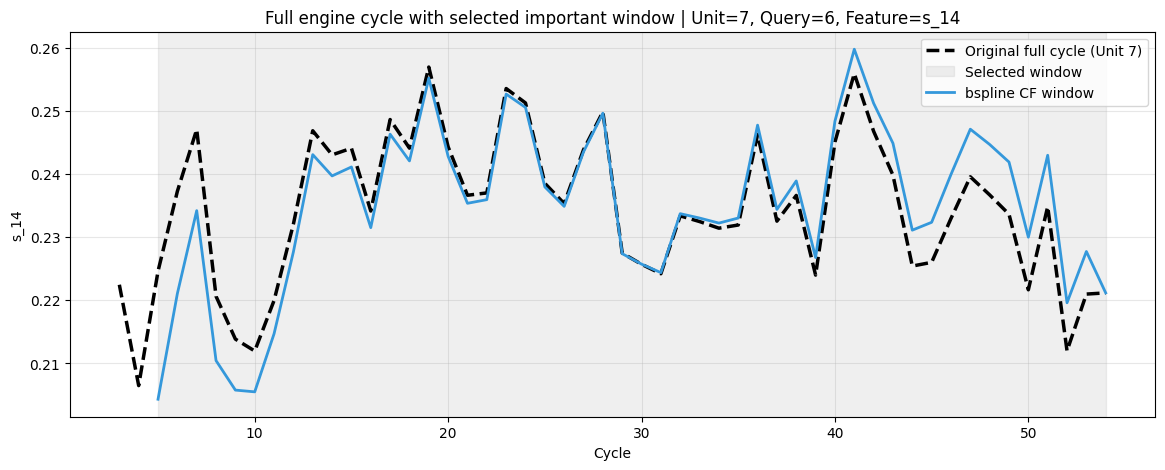

In [61]:
# %%
if cmapss_ds is not None and len(important_windows) > 0:
    best_query_idx = int(important_windows.iloc[0]["query_idx"])
    best_feature = rank_top_sensors_for_query(
        x_vs_xcf_df=x_vs_xcf_df,
        query_idx=best_query_idx,
        method="bspline",
        top_k=1,
    )["feature_name"].iloc[0]

    plot_full_unit_feature_with_window(
        full_test_df=full_test_df,
        query_meta_df=query_meta_df,
        x_vs_xcf_df=x_vs_xcf_df,
        unit_id=unit_id,
        query_idx=best_query_idx,
        feature_name=best_feature,
        method="bspline",
        cf_id=0,
        save_path=f"figures/{SUBSET}_unit{unit_id}_best_window_{best_feature}.png",
    )

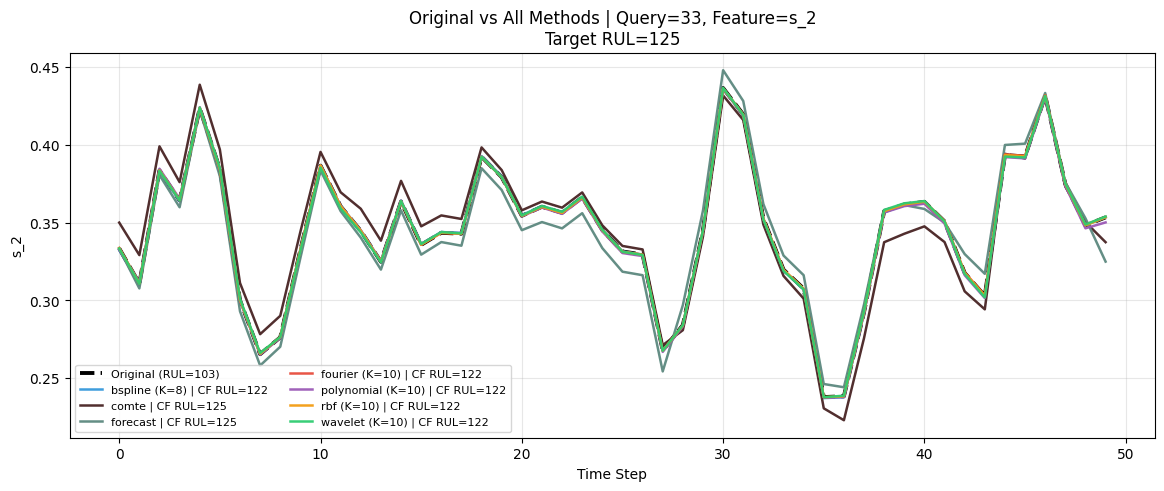

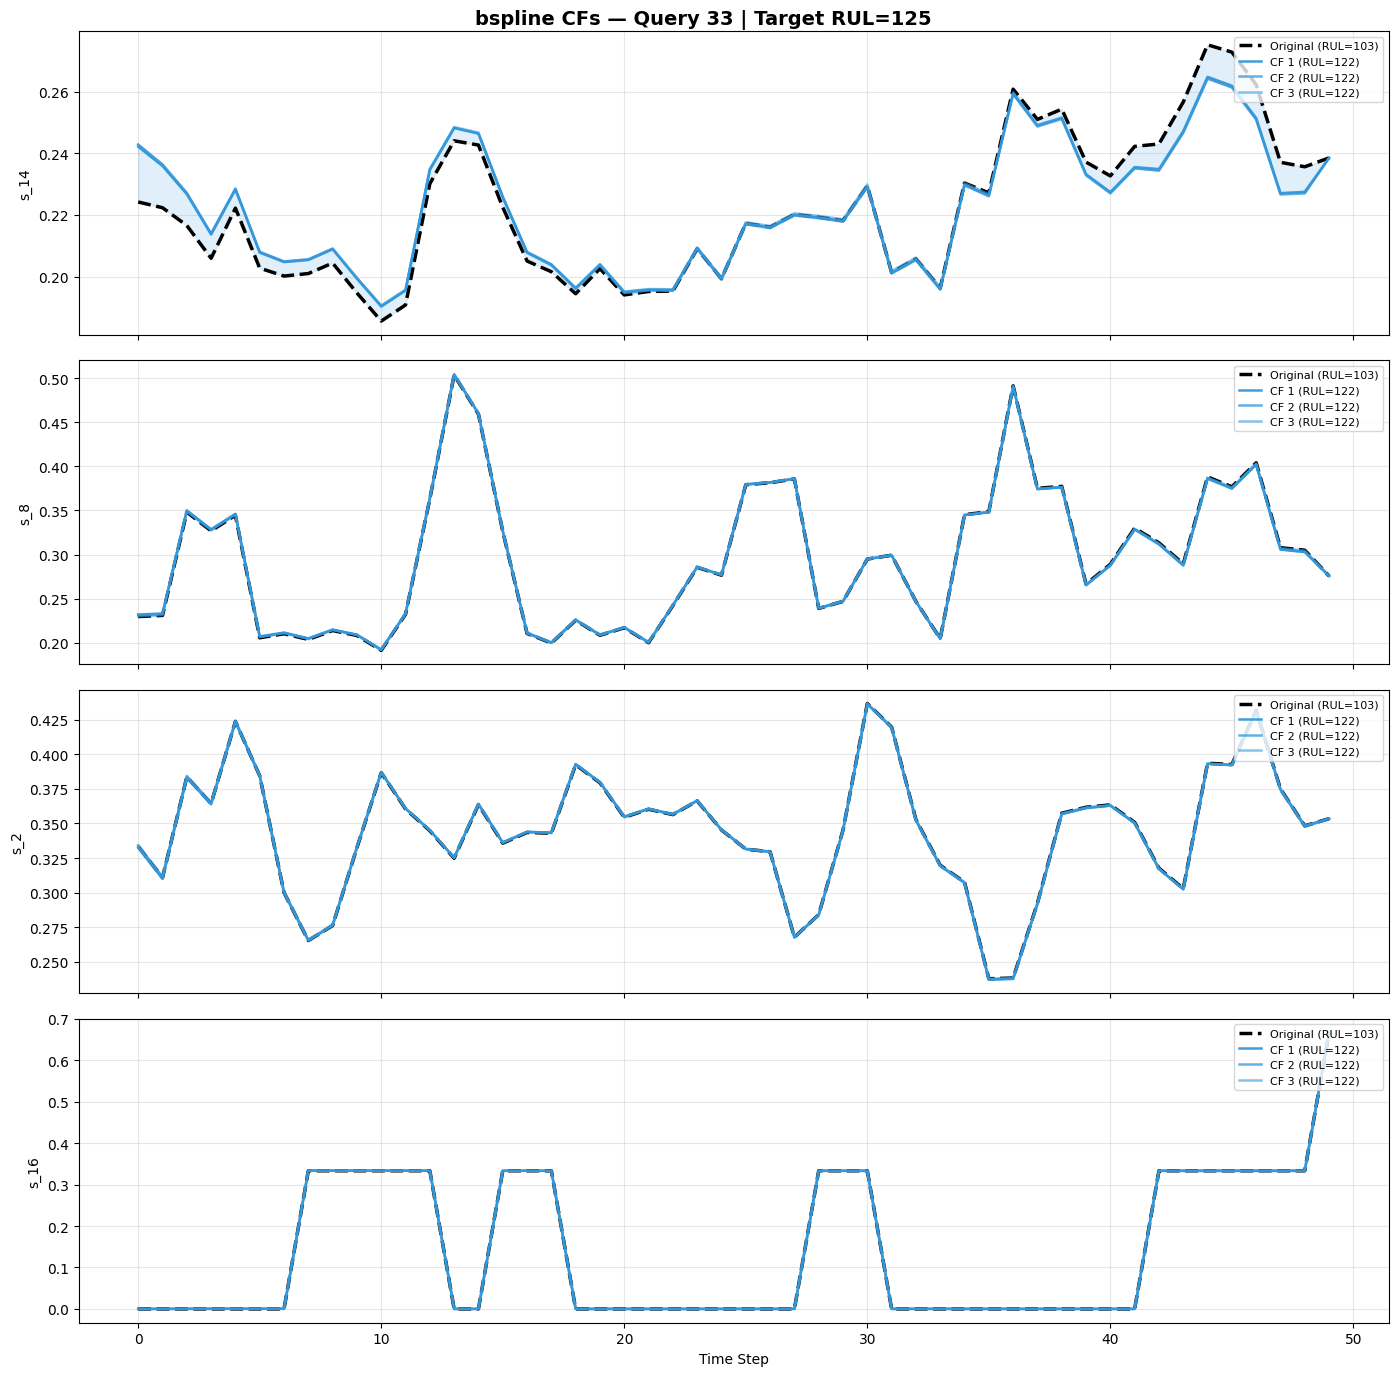

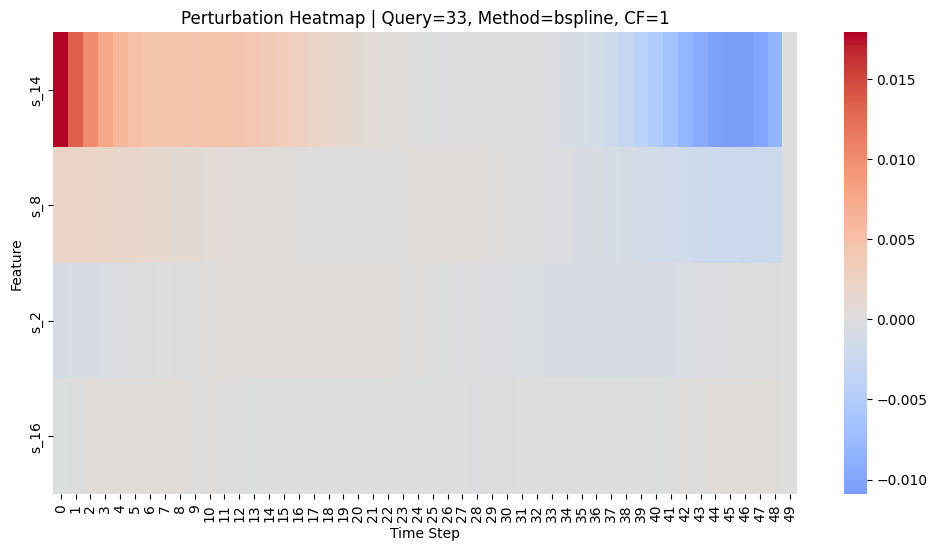

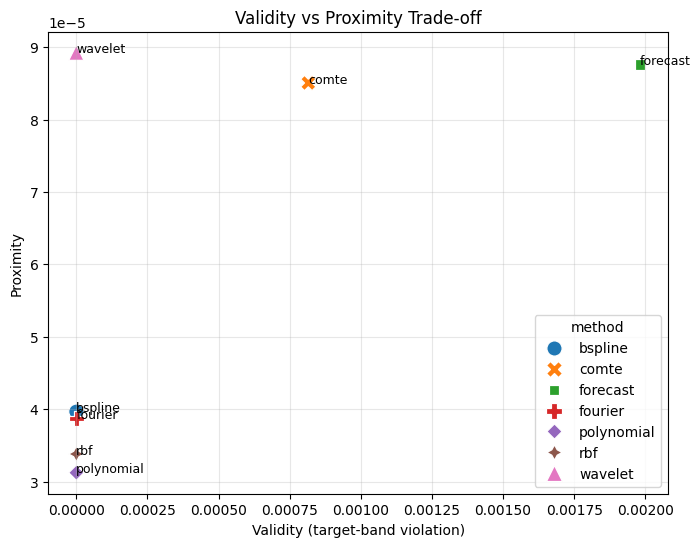

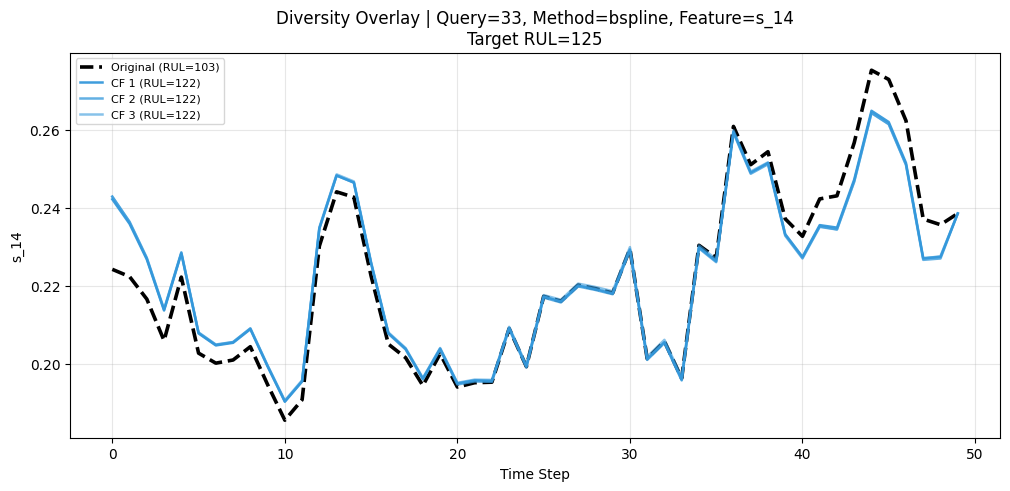

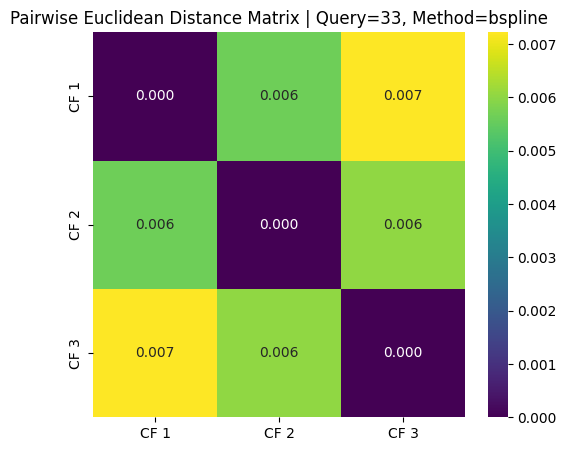

Diversity score: 0.0062866332861466305


In [66]:
# %%
example_query = int(query_indices[0])

plot_window_all_methods_overlay(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    feature_name=feature_cols[sensor_idxs[0]],
    cf_id=0,
    save_path=f"figures/{SUBSET}_query{example_query}_all_methods_overlay.png",
)

plot_window_method_top_features(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    top_n=4,
    save_path=f"figures/{SUBSET}_query{example_query}_bspline_top4.png",
)

plot_window_perturbation_heatmap(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    cf_id=0,
    save_path=f"figures/{SUBSET}_query{example_query}_bspline_heatmap.png",
)

plot_validity_vs_proximity(
    eval_df=eval_df,
    aggregate=True,
    save_path=f"figures/{SUBSET}_validity_vs_proximity.png",
)

top_feat = top_changed_features_df(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    top_n=1,
    exclude_feature_idxs=settings_idxs,
)["feature_name"].iloc[0]

plot_window_diversity_overlay(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    feature_name=top_feat,
    save_path=f"figures/{SUBSET}_query{example_query}_bspline_diversity_overlay.png",
)

D, div_score = plot_window_diversity_distance_matrix(
    x_vs_xcf_df=x_vs_xcf_df,
    query_idx=example_query,
    method="bspline",
    use="delta",
    save_path=f"figures/{SUBSET}_query{example_query}_bspline_diversity_matrix.png",
)

print("Diversity score:", div_score)